In [ ]:
!pip install kaggle

In [1]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"blossomspine","key":"9ab6979c60c7e62d7a3b8d19a212f189"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d vuppalaadithyasairam/ultrasound-breast-images-for-breast-cancer -p ./data --unzip

Dataset URL: https://www.kaggle.com/datasets/vuppalaadithyasairam/ultrasound-breast-images-for-breast-cancer
License(s): CC0-1.0
 99% 561M/564M [00:01<00:00, 305MB/s]
100% 564M/564M [00:01<00:00, 410MB/s]


In [ ]:
import os
import shutil
import random

# Paths
DATASET_PATH = "/content/data/ultrasound breast classification/train"   # adjust if different
OUTPUT_PATH = "/content/data/ultrasound breast classification/train/train1"

# Classes in dataset
classes = ["benign","malignant"]

# Make sure output train folder exists
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Process each class
for cls in classes:
    src_folder = os.path.join(DATASET_PATH, cls)
    dst_folder = os.path.join(OUTPUT_PATH, cls.replace(" ", "_"))  # replace spaces with underscore
    os.makedirs(dst_folder, exist_ok=True)

    # Get list of images
    images = [f for f in os.listdir(src_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Shuffle to randomize
    random.shuffle(images)

    # Take images
    selected_images = images[:1500]

    # Copy to train folder
    for img in selected_images:
        shutil.copy(os.path.join(src_folder, img), os.path.join(dst_folder, img))

    print(f"{cls}: {len(selected_images)} images copied to {dst_folder}")

print(" Train dataset prepared successfully!")

benign: 1500 images copied to /content/data/ultrasound breast classification/train/train1/benign
malignant: 1500 images copied to /content/data/ultrasound breast classification/train/train1/malignant
 Train dataset prepared successfully!


In [ ]:
train_dir = "/content/data/ultrasound breast classification/train/train1"

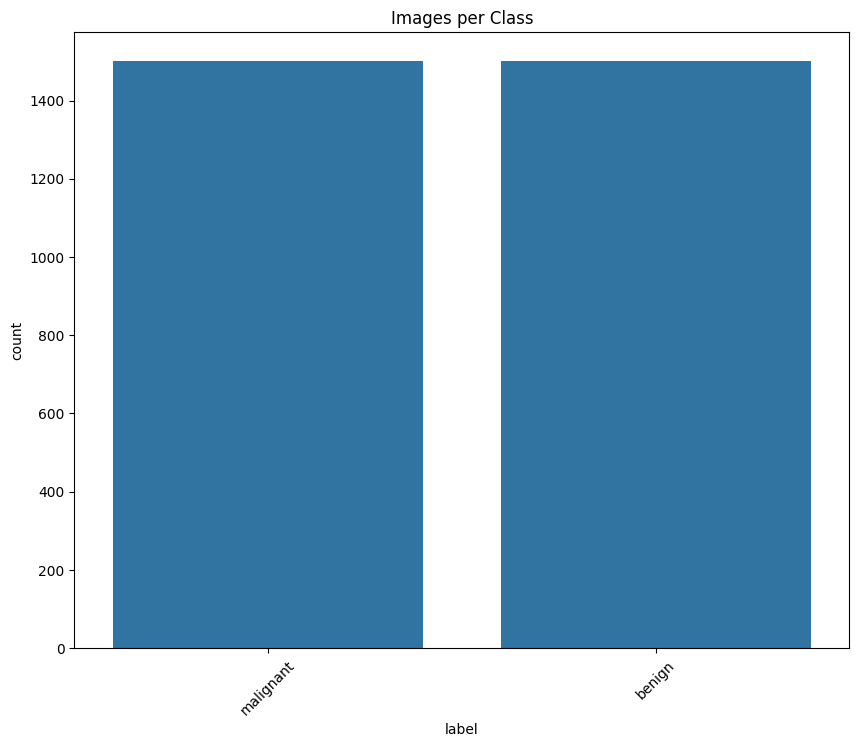

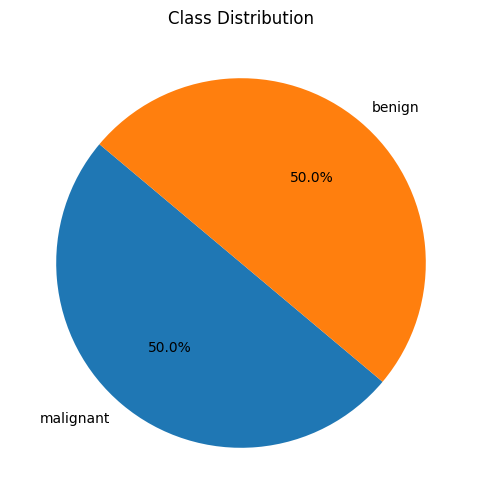

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Count images per class
df = pd.DataFrame([(cls, len(os.listdir(os.path.join(train_dir, cls))))
                   for cls in os.listdir(train_dir)], columns=["label", "count"])

# Bar chart
plt.figure(figsize=(10, 8))
sns.barplot(x="label", y="count", data=df)
plt.xticks(rotation=45)
plt.title("Images per Class")
plt.show()

# Pie chart
df.set_index("label")["count"].plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=140,
    figsize=(6, 6),
)
plt.title("Class Distribution")
plt.ylabel("")
plt.show()

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Build DataFrame with filepaths and labels
df_balanced = pd.DataFrame()
for i, cls in enumerate(os.listdir(train_dir)):
    cls_path = os.path.join(train_dir, cls)
    images = os.listdir(cls_path)
    df_cls = pd.DataFrame({
        "filepath": [os.path.join(cls_path, img) for img in images],
        "label": cls,
        "label_num": str(i)  # numeric label as string
    })
    df_balanced = pd.concat([df_balanced, df_cls], ignore_index=True)

# Train (80%), temp (20%)
train_df, temp_df = train_test_split(
    df_balanced,
    train_size=0.8,
    shuffle=True,
    stratify=df_balanced['label_num'],
    random_state=42
)

# Validation (10%), Test (10%)
valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    shuffle=True,
    stratify=temp_df['label_num'],
    random_state=42
)

# Check sizes
print("Train size:", train_df.shape)
print("Validation size:", valid_df.shape)
print("Test size:", test_df.shape)

# Class balance check
print("\nTrain class distribution:\n", train_df['label_num'].value_counts())
print("\nValidation class distribution:\n", valid_df['label_num'].value_counts())
print("\nTest class distribution:\n", test_df['label_num'].value_counts())

Train size: (2400, 3)
Validation size: (300, 3)
Test size: (300, 3)

Train class distribution:
 label_num
1    1200
0    1200
Name: count, dtype: int64

Validation class distribution:
 label_num
1    150
0    150
Name: count, dtype: int64

Test class distribution:
 label_num
1    150
0    150
Name: count, dtype: int64


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

batch_size = 32
img_size = (224, 224)

# Training data generator with augmentation
tr_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,           # small rotations
    width_shift_range=0.05,      # slight horizontal shift
    height_shift_range=0.05,     # slight vertical shift
    zoom_range=0.1,              # mild zoom
    horizontal_flip=True,        # good for symmetry
    vertical_flip=False,         # not typical for US images
    shear_range=0.05,            # small shear
    fill_mode='nearest'          # fill empty pixels
)

# Validation and test data generator (no augmentation)
ts_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Training generator
train_gen = tr_gen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label_num',
    target_size=img_size, class_mode='sparse',
    color_mode='rgb', shuffle=True, batch_size=batch_size
)

# Validation generator
valid_gen = ts_gen.flow_from_dataframe(
    valid_df, x_col='filepath', y_col='label_num',
    target_size=img_size, class_mode='sparse',
    color_mode='rgb', shuffle=True, batch_size=batch_size
)

# Test generator
test_gen = ts_gen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label_num',
    target_size=img_size, class_mode='sparse',
    color_mode='rgb', shuffle=False, batch_size=batch_size
)


Found 2400 validated image filenames belonging to 2 classes.
Found 300 validated image filenames belonging to 2 classes.
Found 300 validated image filenames belonging to 2 classes.


MobileNetV2 + SE Block

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, Multiply, Reshape
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# --- Squeeze-and-Excitation (SE) Block ---
def se_block(input_tensor, reduction=16):
    channels = input_tensor.shape[-1]
    se = GlobalAveragePooling2D()(input_tensor)
    se = Reshape((1, 1, channels))(se)
    se = Dense(channels // reduction, activation='relu', kernel_initializer='he_normal', use_bias=False)(se)
    se = Dense(channels, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se)
    return Multiply()([input_tensor, se])

# --- MobileNetV2 with SE Block ---
def create_mobilenetv2_senet(input_shape=(224,224,3), num_classes=2):
    inputs = Input(shape=input_shape)
    base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inputs)

    # Freeze most layers (fine-tune last few)
    for layer in base.layers[:-10]:
        layer.trainable = False

    x = base.output

    # Apply SE block
    x = se_block(x)

    # Global pooling and classification head
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

# --- Create and compile the model ---
model = create_mobilenetv2_senet(num_classes=2)
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/tmp/ipython-input-2820604640.py:19: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inputs)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,252,546 (12.41 MB)

 Trainable params: 1,726,018 (6.58 MB)

 Non-trainable params: 1,526,528 (5.82 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint , ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint("best_model.h5", monitor='val_accuracy', save_best_only=True, verbose=1)
]

history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=20,
    callbacks= callbacks,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6216 - loss: 1.0177
Epoch 1: val_accuracy improved from -inf to 0.63000, saving model to best_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 221s 3s/step - accuracy: 0.6227 - loss: 1.0144 - val_accuracy: 0.6300 - val_loss: 0.6344 - learning_rate: 1.0000e-04
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8250 - loss: 0.4123
Epoch 2: val_accuracy improved from 0.63000 to 0.67667, saving model to best_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.8250 - loss: 0.4121 - val_accuracy: 0.6767 - val_loss: 0.7079 - learning_rate: 1.0000e-04
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8803 - loss: 0.2962
Epoch 3: val_accuracy did not improve from 0.67667
75/75 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.8800 - loss: 0.2966 - val_accuracy: 0.6167 - val_loss: 1.2762 - learning_rate: 1.0000e-04
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8789 - loss: 0.2752
Epoch 4: val_accuracy did not improve from 0.67667
75/75 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - accuracy: 0.8790 - loss: 0.2752 - val_accuracy: 0.6067 - val_loss: 1.5237 - learning_rate: 1.0000e-04
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8998 - loss: 0.2592
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 5: val_accuracy did not improve from 0.67667
75/75 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.8997 - loss: 0.2593 - val_accuracy:

75/75 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.9173 - loss: 0.1887 - val_accuracy: 0.6867 - val_loss: 1.5308 - learning_rate: 2.5000e-05
Epoch 10/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9359 - loss: 0.1595
Epoch 10: val_accuracy improved from 0.68667 to 0.70333, saving model to best_model.h5


...

75/75 ━━━━━━━━━━━━━━━━━━━━ 164s 2s/step - accuracy: 0.9451 - loss: 0.1477 - val_accuracy: 0.7567 - val_loss: 1.0398 - learning_rate: 2.5000e-05
Epoch 15/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9392 - loss: 0.1419
Epoch 15: val_accuracy improved from 0.75667 to 0.82000, saving model to best_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.9391 - loss: 0.1422 - val_accuracy: 0.8200 - val_loss: 0.6678 - learning_rate: 2.5000e-05
Epoch 16/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9419 - loss: 0.1448
Epoch 16: val_accuracy improved from 0.82000 to 0.83667, saving model to best_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.9419 - loss: 0.1447 - val_accuracy: 0.8367 - val_loss: 0.5892 - learning_rate: 2.5000e-05
Epoch 17/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9224 - loss: 0.1776
Epoch 17: val_accuracy did not improve from 0.83667
75/75 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - accuracy: 0.9226 - loss: 0.1772 - val_accuracy: 0.8033 - val_loss: 0.6914 - learning_rate: 2.5000e-05
Epoch 18/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9451 - loss: 0.1307
Epoch 18: val_accuracy improved from 0.83667 to 0.85000, saving model to best_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.9450 - loss: 0.1308 - val_accuracy: 0.8500 - val_loss: 0.5414 - learning_rate: 2.5000e-05
Epoch 19/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9467 - loss: 0.1465
Epoch 19: val_accuracy did not improve from 0.85000
75/75 ━━━━━━━━━━━━━━━━━━━━ 183s 2s/step - accuracy: 0.9467 - loss: 0.1464 - val_accuracy: 0.8400 - val_loss: 0.5511 - learning_rate: 2.5000e-05
Epoch 20/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9441 - loss: 0.1283
Epoch 20: val_accuracy improved from 0.85000 to 0.85667, saving model to best_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.9441 - loss: 0.1283 - val_accuracy: 0.8567 - val_loss: 0.4461 - learning_rate: 2.5000e-05
Restoring model weights from the end of the best epoch: 20.


In [ ]:
loss, accuracy = model.evaluate(test_gen, verbose=1)

print(f"Final Test Accuracy: {accuracy*100:.2f}%")
print(f"Final Test Loss: {loss:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.8553 - loss: 0.3388
Final Test Accuracy: 86.67%
Final Test Loss: 0.3547


In [ ]:
from tensorflow.keras.models import load_model

# Load the best saved model
best_model = load_model('best_model.h5')



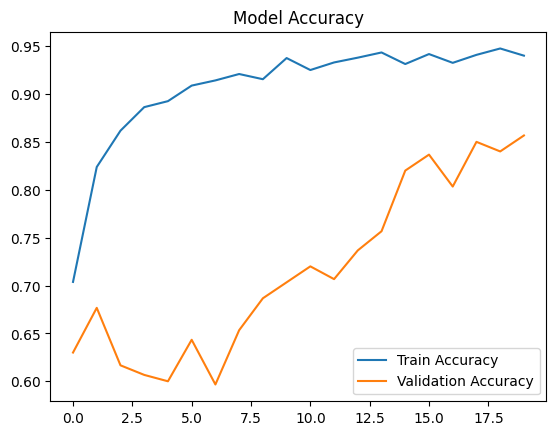

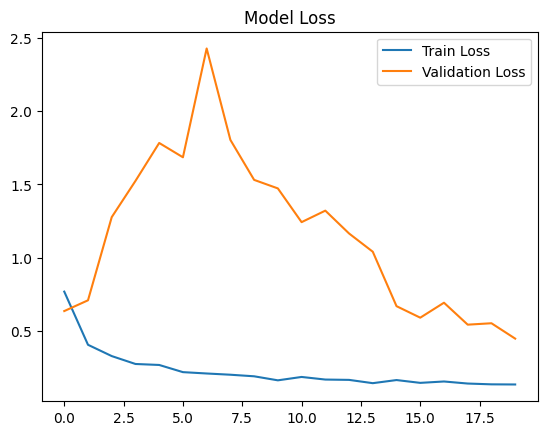

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step

Classification Report:
              precision    recall  f1-score   support

           0       0.79      1.00      0.88       150
           1       1.00      0.73      0.85       150

    accuracy                           0.87       300
   macro avg       0.89      0.87      0.86       300
weighted avg       0.89      0.87      0.86       300



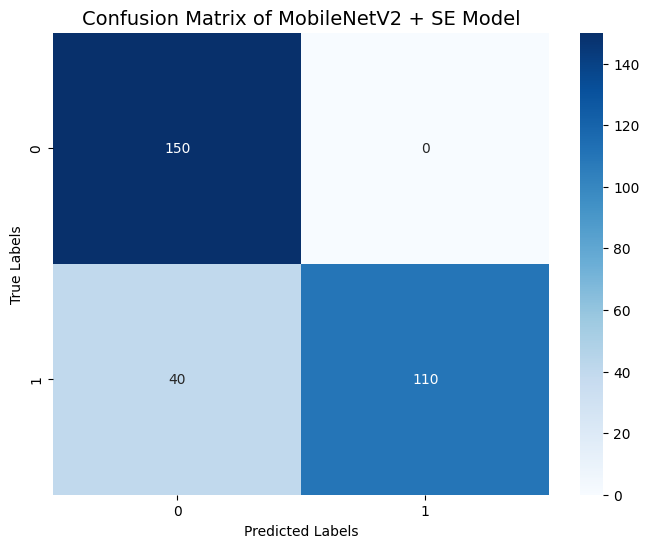

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- True labels from test generator ---
y_true = test_gen.classes

# --- Predictions from the best model ---
y_pred = np.argmax(best_model.predict(test_gen), axis=1)

# --- Classification report ---
print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_gen.class_indices.keys())
))

# --- Confusion matrix ---
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=test_gen.class_indices.keys(),
    yticklabels=test_gen.class_indices.keys()
)
plt.title("Confusion Matrix of MobileNetV2 + SE Model", fontsize=14)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


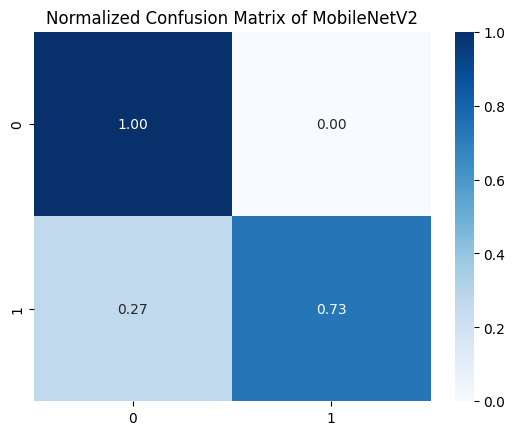

In [ ]:

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())
plt.title("Normalized Confusion Matrix of MobileNetV2")
plt.show()


Grad-CAM for class 1: /content/data/ultrasound breast classification/train/train1/benign/benign (237)-sharpened-rotated2.png


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


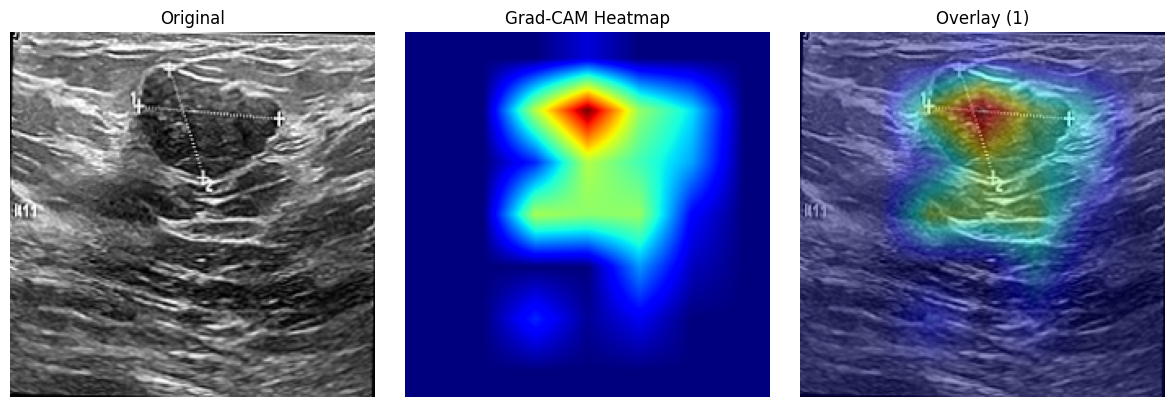

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted class id: 1 | Probability: 0.779
True class: 1

Grad-CAM for class 0: /content/data/ultrasound breast classification/train/train1/malignant/malignant (38)-rotated32.png


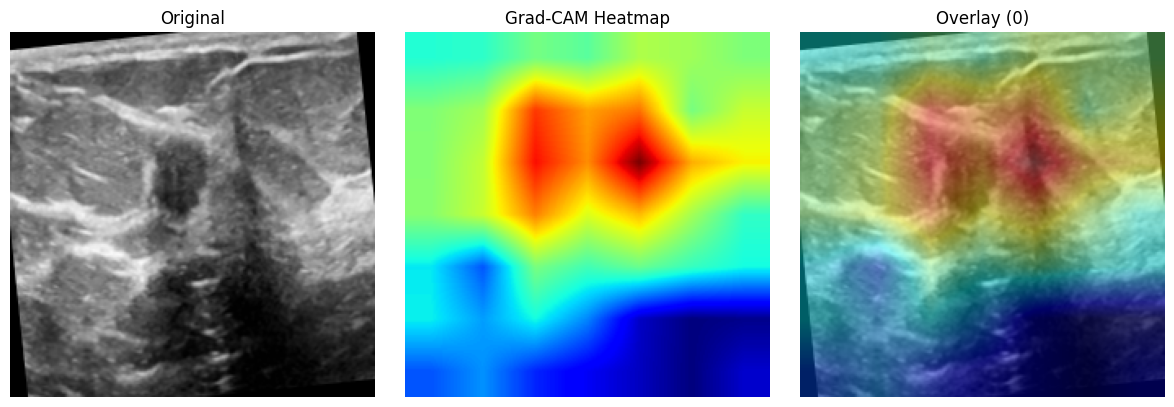

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
Predicted class id: 0 | Probability: 0.999
True class: 0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
import cv2

# ---------- Grad-CAM function ----------
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="Conv_1", pred_index=None):
    """
    Generates Grad-CAM heatmap for a single image.
    """
    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize heatmap
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# ---------- Display function ----------
def display_gradcam(img_path, model, class_name=None, last_conv_layer_name="Conv_1", alpha=0.4):
    """
    Load image, generate Grad-CAM, and display original, heatmap, and overlay.
    """
    img_size = (224, 224)
    # Load & preprocess
    img = tf.keras.utils.load_img(img_path, target_size=img_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array_exp = np.expand_dims(img_array, axis=0)
    img_array_exp = tf.keras.applications.mobilenet_v2.preprocess_input(img_array_exp)

    # Grad-CAM
    heatmap = make_gradcam_heatmap(img_array_exp, model, last_conv_layer_name)

    # Resize and overlay
    heatmap_resized = cv2.resize(heatmap, img_size)
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    original_img = cv2.imread(img_path)
    original_img = cv2.resize(original_img, img_size)

    overlay_img = cv2.addWeighted(original_img, 1 - alpha, heatmap_color, alpha, 0)

    # Plot results
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_resized, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB))
    title_str = "Overlay"
    if class_name:
        title_str += f" ({class_name})"
    plt.title(title_str)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # Prediction info
    preds = model.predict(img_array_exp)
    pred_idx = np.argmax(preds)
    pred_prob = preds[0][pred_idx]
    print(f"Predicted class id: {pred_idx} | Probability: {pred_prob:.3f}")
    if class_name:
        print(f"True class: {class_name}")

# ---------- Pick one sample image per class ----------
class_ids = test_df['label_num'].unique()
sample_imgs = []
for cls in class_ids:
    img_path = test_df[test_df['label_num'] == cls]['filepath'].iloc[0]
    sample_imgs.append((img_path, cls))

# ---------- Display Grad-CAM for each class ----------
for img_path, cls in sample_imgs:
    class_name = str(cls)  # Optionally map numeric class to actual name
    print(f"\nGrad-CAM for class {cls}: {img_path}")
    display_gradcam(img_path, best_model, class_name=class_name, last_conv_layer_name="Conv_1")
